# Custom Model from Scratch (NumPy only)

Two classifiers built by hand — no `sklearn`/`torch` for the models themselves, only NumPy.

1. **Logistic regression** — a single sigmoid unit trained with batch gradient descent.
2. **A small 2-layer neural network** — one `tanh` hidden layer + a sigmoid output, trained with full backpropagation.

We train both on the **two-moons** dataset, which is *not* linearly separable. Logistic regression can only draw a straight line, so it plateaus; the neural net bends its decision boundary and separates the classes. The gap between them is exactly what the hidden layer + backprop buys you.

`sklearn` appears only to *generate* the data and split it — never inside a model.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)     # module-level Generator
np.random.seed(42)                  # legacy global RNG

## 1. Data

`X` has shape `(n_samples, 2)` and `y` is a 0/1 label. We standardize the features (zero mean, unit variance) using **only the training statistics** — gradient descent converges far faster on scaled inputs, and applying test data with train stats avoids leakage.

train: (750, 2), test: (250, 2)


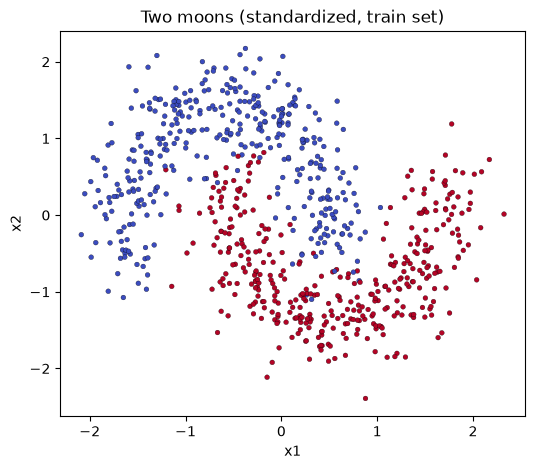

In [2]:
X, y = make_moons(n_samples=1000, noise=0.20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Standardize with train-set statistics only
mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

# Reshape labels to column vectors (n, 1) so they broadcast cleanly with predictions
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print(f"train: {X_train.shape}, test: {X_test.shape}")

plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.ravel(), cmap="coolwarm", s=12, edgecolor="k", linewidth=0.2)
plt.title("Two moons (standardized, train set)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

## Shared helpers

The **sigmoid** squashes any real number into (0, 1) so it reads as a probability:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

We use a numerically stable version (splitting on the sign of `z`) so large-magnitude inputs don't overflow `exp`.

The loss is **binary cross-entropy** (a.k.a. log-loss), averaged over the batch, with a tiny `eps` inside the log to avoid `log(0)`:

$$\mathcal{L} = -\frac{1}{m}\sum_{i=1}^{m}\Big[ y_i \log \hat{y}_i + (1 - y_i)\log(1 - \hat{y}_i) \Big]$$

In [3]:
def sigmoid(z):
    """Numerically stable logistic sigmoid."""
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out


def bce_loss(y_true, y_pred, eps=1e-12):
    """Mean binary cross-entropy."""
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def accuracy(y_true, y_pred_prob):
    return np.mean((y_pred_prob >= 0.5).astype(int) == y_true)


def plot_decision_boundary(predict_prob, X, y, title):
    """Contour the model's probability over a grid, overlay the data."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = predict_prob(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, probs, levels=25, cmap="coolwarm", alpha=0.7)
    plt.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=1.2)
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="coolwarm", s=12, edgecolor="k", linewidth=0.2)
    plt.title(title); plt.xlabel("x1"); plt.ylabel("x2")
    plt.show()

## 2. Logistic regression from scratch

**Model.** For a feature matrix $X \in \mathbb{R}^{m \times n}$, weights $w \in \mathbb{R}^{n \times 1}$, and bias $b$:

$$z = Xw + b, \qquad \hat{y} = \sigma(z)$$

**Gradients.** A convenient property of sigmoid + cross-entropy is that the messy chain rule collapses to a clean residual $(\hat{y} - y)$:

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{1}{m} X^{\top} (\hat{y} - y), \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{m}\sum (\hat{y} - y)$$

**Update (gradient descent).** Step downhill by the learning rate $\eta$:

$$w \leftarrow w - \eta \frac{\partial \mathcal{L}}{\partial w}, \qquad b \leftarrow b - \eta \frac{\partial \mathcal{L}}{\partial b}$$

train acc: 0.859
test  acc: 0.904


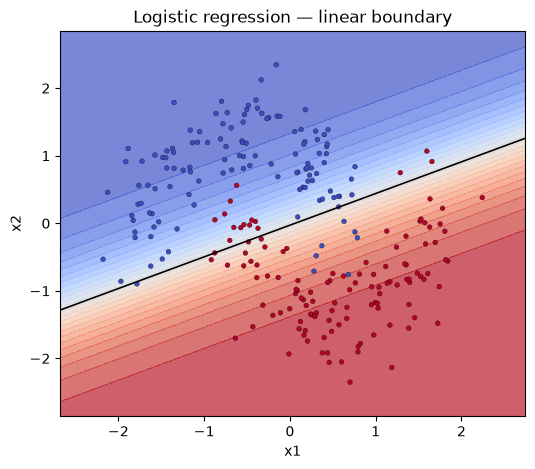

In [4]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.5, n_iters=2000):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = 0.0
        self.history = []

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros((n, 1))
        self.b = 0.0
        for i in range(self.n_iters):
            # forward
            z = X @ self.w + self.b
            y_hat = sigmoid(z)
            # gradients
            error = y_hat - y                      # (m, 1)
            dw = (X.T @ error) / m                  # (n, 1)
            db = np.mean(error)
            # gradient-descent step
            self.w -= self.lr * dw
            self.b -= self.lr * db
            if i % 50 == 0:
                self.history.append(bce_loss(y, y_hat))
        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)


logreg = LogisticRegressionScratch(lr=0.5, n_iters=2000).fit(X_train, y_train)

print(f"train acc: {accuracy(y_train, logreg.predict_proba(X_train)):.3f}")
print(f"test  acc: {accuracy(y_test,  logreg.predict_proba(X_test)):.3f}")

plot_decision_boundary(logreg.predict_proba, X_test, y_test, "Logistic regression — linear boundary")

The boundary is a straight line, so it can't follow the curve between the two moons — accuracy tops out around the high-80s%. That's the ceiling for a linear model here.

## 3. A 2-layer neural network from scratch

Architecture: `2 inputs → H tanh hidden units → 1 sigmoid output`.

**Forward pass**
$$Z_1 = X W_1 + b_1, \quad A_1 = \tanh(Z_1)$$
$$Z_2 = A_1 W_2 + b_2, \quad A_2 = \sigma(Z_2) = \hat{y}$$

**Backpropagation** (chain rule, layer by layer). Using $\frac{d}{dz}\tanh(z) = 1 - \tanh^2(z)$:
$$dZ_2 = A_2 - y$$
$$dW_2 = \tfrac{1}{m} A_1^{\top} dZ_2, \qquad db_2 = \tfrac{1}{m}\textstyle\sum dZ_2$$
$$dZ_1 = (dZ_2 \, W_2^{\top}) \odot (1 - A_1^2)$$
$$dW_1 = \tfrac{1}{m} X^{\top} dZ_1, \qquad db_1 = \tfrac{1}{m}\textstyle\sum dZ_1$$

Then the same gradient-descent update on every parameter. Weights are initialized small and random (not zero) to **break symmetry** — if all hidden units started identical they'd stay identical and the hidden layer would be useless.

train acc: 0.976
test  acc: 0.988


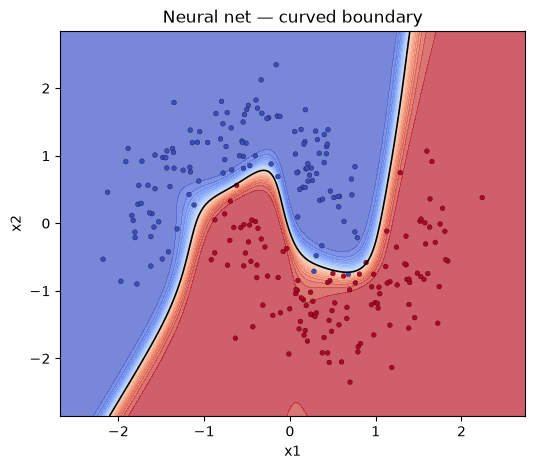

In [5]:
class NeuralNetScratch:
    def __init__(self, n_hidden=8, lr=0.5, n_iters=5000, seed=42):
        self.n_hidden = n_hidden
        self.lr = lr
        self.n_iters = n_iters
        self.seed = seed
        self.history = []

    def _init_params(self, n_features):
        rng = np.random.default_rng(self.seed)
        # Xavier-ish scaling keeps activations from saturating early
        self.W1 = rng.standard_normal((n_features, self.n_hidden)) * np.sqrt(1.0 / n_features)
        self.b1 = np.zeros((1, self.n_hidden))
        self.W2 = rng.standard_normal((self.n_hidden, 1)) * np.sqrt(1.0 / self.n_hidden)
        self.b2 = np.zeros((1, 1))

    def _forward(self, X):
        Z1 = X @ self.W1 + self.b1
        A1 = np.tanh(Z1)
        Z2 = A1 @ self.W2 + self.b2
        A2 = sigmoid(Z2)
        cache = (X, A1, A2)
        return A2, cache

    def fit(self, X, y):
        m, n = X.shape
        self._init_params(n)
        for i in range(self.n_iters):
            # ---- forward ----
            A2, (X_, A1, _) = self._forward(X)

            # ---- backward ----
            dZ2 = A2 - y                              # (m, 1)
            dW2 = (A1.T @ dZ2) / m                     # (H, 1)
            db2 = np.mean(dZ2, axis=0, keepdims=True)  # (1, 1)

            dZ1 = (dZ2 @ self.W2.T) * (1 - A1 ** 2)    # (m, H), tanh'
            dW1 = (X_.T @ dZ1) / m                     # (n, H)
            db1 = np.mean(dZ1, axis=0, keepdims=True)  # (1, H)

            # ---- gradient-descent update ----
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1

            if i % 100 == 0:
                self.history.append(bce_loss(y, A2))
        return self

    def predict_proba(self, X):
        A2, _ = self._forward(X)
        return A2


nn = NeuralNetScratch(n_hidden=8, lr=0.5, n_iters=5000).fit(X_train, y_train)

print(f"train acc: {accuracy(y_train, nn.predict_proba(X_train)):.3f}")
print(f"test  acc: {accuracy(y_test,  nn.predict_proba(X_test)):.3f}")

plot_decision_boundary(nn.predict_proba, X_test, y_test, "Neural net — curved boundary")

## 4. Compare

Loss curves and final test accuracy side by side. The neural net drives its loss lower and follows the moon shape, landing in the mid-to-high 90s% where logistic regression stalls.

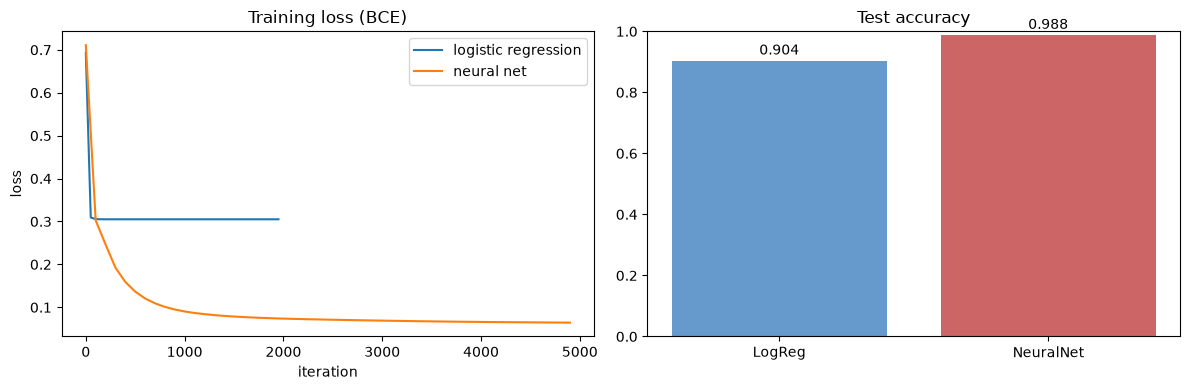

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(np.arange(len(logreg.history)) * 50, logreg.history, label="logistic regression")
ax[0].plot(np.arange(len(nn.history)) * 100, nn.history, label="neural net")
ax[0].set_title("Training loss (BCE)"); ax[0].set_xlabel("iteration"); ax[0].set_ylabel("loss")
ax[0].legend()

models = ["LogReg", "NeuralNet"]
test_accs = [
    accuracy(y_test, logreg.predict_proba(X_test)),
    accuracy(y_test, nn.predict_proba(X_test)),
]
bars = ax[1].bar(models, test_accs, color=["#6699cc", "#cc6666"])
ax[1].set_ylim(0, 1); ax[1].set_title("Test accuracy")
for bar, acc in zip(bars, test_accs):
    ax[1].text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f"{acc:.3f}", ha="center")

plt.tight_layout(); plt.show()

## 5. Gradient check (sanity test for backprop)

Backprop is easy to get subtly wrong. We verify the analytic gradient against a **numerical** one computed by finite differences:

$$\frac{\partial \mathcal{L}}{\partial \theta} \approx \frac{\mathcal{L}(\theta + \epsilon) - \mathcal{L}(\theta - \epsilon)}{2\epsilon}$$

If the relative difference is tiny (~1e-7), the hand-derived gradients are correct.

In [7]:
def gradient_check(model, X, y, eps=1e-5):
    # analytic gradient for W1 via one backward pass
    A2, (X_, A1, _) = model._forward(X)
    m = X.shape[0]
    dZ2 = A2 - y
    dZ1 = (dZ2 @ model.W2.T) * (1 - A1 ** 2)
    dW1_analytic = (X_.T @ dZ1) / m

    # numerical gradient for a few random entries of W1
    rng = np.random.default_rng(0)
    idx = [(int(rng.integers(model.W1.shape[0])), int(rng.integers(model.W1.shape[1]))) for _ in range(5)]
    max_rel = 0.0
    for (i, j) in idx:
        orig = model.W1[i, j]
        model.W1[i, j] = orig + eps
        loss_plus = bce_loss(y, model._forward(X)[0])
        model.W1[i, j] = orig - eps
        loss_minus = bce_loss(y, model._forward(X)[0])
        model.W1[i, j] = orig
        num = (loss_plus - loss_minus) / (2 * eps)
        ana = dW1_analytic[i, j]
        rel = abs(num - ana) / max(1e-12, abs(num) + abs(ana))
        max_rel = max(max_rel, rel)
        print(f"W1[{i},{j}]  analytic={ana:+.6e}  numeric={num:+.6e}  rel_diff={rel:.2e}")
    print(f"\nmax relative difference: {max_rel:.2e}  ->  {'PASS' if max_rel < 1e-5 else 'CHECK'}")


gradient_check(nn, X_train, y_train)

W1[1,5]  analytic=+2.431691e-04  numeric=+2.431691e-04  rel_diff=5.79e-10
W1[1,2]  analytic=-2.342425e-04  numeric=-2.342425e-04  rel_diff=1.10e-09
W1[0,0]  analytic=+4.366509e-05  numeric=+4.366509e-05  rel_diff=1.14e-08
W1[0,0]  analytic=+4.366509e-05  numeric=+4.366509e-05  rel_diff=1.14e-08
W1[0,6]  analytic=-4.972730e-04  numeric=-4.972730e-04  rel_diff=8.60e-10

max relative difference: 1.14e-08  ->  PASS
